# **Deserción en Gimnasios - Dataset**

**Descripción:**

Este conjunto de datos reúne información sobre el comportamiento, las características demográficas y los registros de actividad de los socios de un gimnasio. Su propósito es identificar patrones relacionados con la permanencia de los clientes y analizar los factores que influyen en su abandono o cancelación de la membresía.

**Fuente:** Kaggle: https://www.kaggle.com/datasets/hassaan2580/churn-prediction-gym-members-dataset

Cada fila representa a un miembro del gimnasio e incluye información personal, detalles de su membresía y registros de uso y entrenamiento.

**Variables principales:**
- ID de miembro
- Nombre (anonimizado)
- Edad, género, dirección y teléfono
- Tipo de membresía
- Fecha de ingreso y última visita
- Ejercicio favorito
- Duración promedio del entrenamiento
- Calorías promedio quemadas
- Peso total levantado
- Visitas por mes
- Abandono de membresía (Churn)

Estos datos permiten analizar la actividad de los socios, sus hábitos de entrenamiento y los factores asociados a la retención o deserción dentro del gimnasio.

El conjunto de datos contiene **150 filas (miembros)** y **15 columnas (variables)**.

# **Importación de Librerías**

Importamos las librerías necesarias para el proceso EDA

In [5]:
# Importamos pandas para el manejo de tablas (DataFrames)
import pandas as pd

# Importamos numpy para operaciones matemáticas y manejo de valores nulos
import numpy as np

# Importamos matplotlib y seaborn para las visualizaciones y gráficos
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# **Carga del Conjunto de Datos**

Aquí leemos el archivo CSV. Asegúrate de que el archivo. Y para asegurarnos de que la estructura sea correcta y ver qué aspecto tienen los primeros registros, imprimimos las primeras 5 filas.

In [6]:
# Cargamos el dataset indicando el nombre exacto del archivo
df = pd.read_csv('gym_members_dataset.csv')

# Primeros 5 registros del conjunto de datos
df.head()

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
1,2,Shanza,19.0,Female,"Street 111, City 18",039-19243328,Monthly,2023-12-04,2024-02-14,Squats,37,436.0,4612.0,11.0,No
2,3,Ubaidullah,52.0,Male,"Street 69, City 21",033-60221501,Quarterly,2024-09-13,2024-12-07,Bench Press,98,523.0,3124.0,4.0,Yes
3,4,Mansoor Ahmed,52.0,Male,"Street 72, City 39",035-55527902,Monthly,2024-06-05,2025-02-24,Pull-ups,66,282.0,4586.0,24.0,No
4,5,Hanzala,32.0,Male,"Street 6, City 12",038-93946322,Monthly,2022-06-15,2022-12-02,Bench Press,32,522.0,16353.0,18.0,No


En una primera revisión del dataset, no se observan muchos errores evidentes. Solo se identifica un valor faltante (NaN) en la columna Name, al menos según esta inspección inicia.

# **Dimensiones del Dataset**

Es fundamental conocer con cuánta información contamos antes de comenzar su procesamiento, es decir, determinar cuántos registros y cuántas características contiene el conjunto de datos. Aunque en una primera instancia la descripción se basó en la información proporcionada por Kaggle, resulta conveniente verificar directamente en una situación real si el dataset efectivamente presenta la estructura y características descritas en su documentación.

In [7]:
# df.shape devuelve una tupla: (filas, columnas)
df.shape

(150, 15)

En este caso, al igual que en la descripción proporcionada, se mantiene la misma cantidad de filas y columnas, lo que representa un aspecto positivo para el análisis. El conjunto de datos cuenta con **150 filas (registros)** y **15 columnas (características)**, coincidiendo con la información originalmente descrita.

# **Tipos de Datos y Estructura Básica**

Identificar los tipos de datos y la estructura del conjunto de datos mediante herramientas como df.info() es un buen punto de partida para el análisis. Esta función permite conocer la cantidad de columnas y registros disponibles, además de proporcionar una visión general sobre la presencia de valores nulos en cada variable. Asimismo, facilita la verificación de que los tipos de datos asignados a cada columna sean los adecuados, lo que resulta fundamental antes de realizar tareas de limpieza, transformación o modelado de datos.

In [8]:
# Muestra un resumen del tipo de datos por columna y la memoria utilizada
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Member_ID                 150 non-null    int64  
 1   Name                      127 non-null    str    
 2   Age                       137 non-null    float64
 3   Gender                    150 non-null    str    
 4   Address                   150 non-null    str    
 5   Phone_Number              150 non-null    str    
 6   Membership_Type           150 non-null    str    
 7   Join_Date                 141 non-null    str    
 8   Last_Visit_Date           150 non-null    str    
 9   Favorite_Exercise         150 non-null    str    
 10  Avg_Workout_Duration_Min  150 non-null    int64  
 11  Avg_Calories_Burned       139 non-null    float64
 12  Total_Weight_Lifted_kg    142 non-null    float64
 13  Visits_Per_Month          138 non-null    float64
 14  Churn                

A primera vista, se observan posibles valores nulos en variables como Name, Age, Join_Date, Total_Weight_Lifted_kg y Visits_per_month.
Además, algunos tipos de datos parecen no ser los más adecuados. Por ejemplo, Age y Visits_per_month se encuentran como float, cuando probablemente deberían ser int, ya que representan conteos. Del mismo modo, Join_Date y Last_Visit_Date están almacenadas como str, aunque sería más conveniente tratarlas como datetime para facilitar el análisis temporal. Finalmente, la variable objetivo contiene únicamente valores Yes y No, por lo que podría ser más apropiado manejarla como una variable categórica o booleana.

# **Análisis Estadístico Descriptivo**

En esta sección, calcularemos las estadísticas básicas para entender cómo se distribuyen nuestros datos numéricos (medias, desviaciones estándar, mínimos y máximos) y analizaremos la frecuencia de nuestras variables categóricas.

## **Variables Numéricas**

Las variables numéricas presentan distribuciones relativamente equilibradas, ya que la media y la mediana son similares en la mayoría de los casos. Además, se confirma la presencia de datos faltantes en varias columnas, reforzando lo observado previamente con df.info(). Por otro lado, la variable Total_Weight_Lifted_kg muestra una alta variabilidad, por lo que sería conveniente analizarla mediante histogramas o diagramas de caja para detectar posibles valores atípicos.

In [9]:
# Estadísticas descriptivas para variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Member_ID,150.0,75.500000,43.445368,1.0,38.25,75.5,112.75,150.0
Age,137.0,35.905109,11.654892,18.0,25.00,36.0,46.00,54.0
Avg_Workout_Duration_Min,150.0,73.326667,25.879560,30.0,53.00,74.0,94.50,119.0
Avg_Calories_Burned,139.0,488.309353,168.649317,209.0,341.50,496.0,627.50,788.0
Total_Weight_Lifted_kg,142.0,9486.978873,5127.955128,1009.0,5274.00,9072.5,13620.75,19722.0
Visits_Per_Month,138.0,14.224638,6.385451,4.0,8.00,14.0,20.00,24.0


## **Variables Categóricas**

El análisis de las variables categóricas muestra que la mayoría presentan una alta diversidad de valores. Name contiene 127 registros válidos y 122 nombres únicos, lo que confirma la existencia de datos faltantes. Algo similar ocurre con Join_Date, que posee 141 registros válidos y 131 fechas distintas. Por otro lado, variables como Gender y Churn presentan únicamente dos categorías, mientras que Membership_Type cuenta con tres tipos de membresía y Favorite_Exercise con seis tipos de ejercicios. Además, se observa que la clase objetivo Churn está desbalanceada, ya que predominan los casos No (111 registros) frente a Yes (39 registros), aspecto que deberá considerarse en etapas posteriores de modelado.

In [10]:
# Distribución de variables categóricas (frecuencias, valores únicos)
df.describe(include='object').T

,count,unique,top,freq
Name,127,122,Laraib,2
Gender,150,2,Male,75
Address,150,149,"Street 72, City 39",2
Phone_Number,150,150,032-51510359,1
Membership_Type,150,3,Monthly,75
Join_Date,141,131,2022-10-10,2
Last_Visit_Date,150,140,2025-03-13,3
Favorite_Exercise,150,6,Deadlift,32
Churn,150,2,No,111


# **Detección y Corrección de Incongruencias Categóricas**

Antes de aplicar cualquier técnica de limpieza, es importante revisar los datos para detectar posibles problemas. En este paso, se identificarán las columnas de texto y se analizarán sus valores únicos junto con su frecuencia. El objetivo es encontrar posibles inconsistencias, como espacios adicionales, errores de escritura o diferencias en el uso de mayúsculas y minúsculas, antes de realizar cualquier modificación en el dataset.

In [11]:
# Le decimos a Pandas que no recorte el contenido de las columnas
pd.set_option('display.max_colwidth', None)

# Definimos explícitamente solo las columnas que queremos analizar
columnas_objetivo = ['Gender', 'Membership_Type', 'Favorite_Exercise', 'Churn']

# Creación de la lista para el diagnóstico
lista_resumen = []

for col in columnas_objetivo:
    # Verificamos que la columna exista en el DataFrame para evitar errores
    if col in df.columns:
        cantidad_unicos = df[col].nunique(dropna=False)
        
        # Extraemos TODOS los valores únicos de la columna y los pasamos a una lista
        todos_los_valores = df[col].unique().tolist()
        
        # Convertimos la lista en una cadena de texto separada por comas
        valores_texto = ", ".join([str(valor) for valor in todos_los_valores])
        
        lista_resumen.append({
            'Variable Categórica': col,
            'Valores Únicos Totales': cantidad_unicos,
            'Todos los Valores Únicos': valores_texto
        })

# 3. Generamos y mostramos el DataFrame
df_auditoria = pd.DataFrame(lista_resumen)
display(df_auditoria)

# (Opcional) Restauramos el límite por defecto de Pandas para no afectar futuras tablas
pd.reset_option('display.max_colwidth')

,Variable Categórica,Valores Únicos Totales,Todos los Valores Únicos
0,Gender,2,"Male, Female"
1,Membership_Type,3,"Quarterly, Monthly, Yearly"
2,Favorite_Exercise,6,"Pull-ups, Squats, Bench Press, Deadlift, Treadmill, Cycling"
3,Churn,2,"No, Yes"


Basado en este análisis, se observa que no existen categorías con valores erróneos o inconsistentes. Esto es una buena señal, ya que no será necesario realizar correcciones relacionadas con este tipo de errores en etapas posteriores del proyecto.

# **Identificación de Valores Nulos, Duplicados y Outliers**

Antes de modelar o concluir, debemos evaluar la calidad de los datos. Identificaremos si existen valores faltantes (nulos) que debamos imputar o eliminar, y detectaremos valores atípicos (outliers) que puedan sesgar nuestro análisis.

## **Detección de Valores Nulos**

In [12]:
nulos_por_columna = df.isnull().sum()
nulos_filtrados = nulos_por_columna[nulos_por_columna > 0]

# Conteo valores Nulos
if nulos_filtrados.empty:
    print("No existen datos Nulos")
else:
    print(nulos_filtrados)

Name                      23
Age                       13
Join_Date                  9
Avg_Calories_Burned       11
Total_Weight_Lifted_kg     8
Visits_Per_Month          12
dtype: int64


Antes de imputar valores faltantes, es recomendable investigar el mecanismo de ausencia de los datos. Si los valores faltantes no son completamente aleatorios, una **imputación simple** con **mediana** o **moda** podría introducir **sesgos** en el **análisis**.

Por ello, además de evaluar la proporción de datos faltantes, conviene analizar si existe alguna relación entre los nulos y otras variables del conjunto de datos, para así seleccionar una estrategia de imputación más adecuada. Esto es especialmente importante en variables como **Age**, **Visits_Per_Month** y **Total_Weight_Lifted_kg**, que podrían estar asociadas al comportamiento de abandono de los clientes.

## **Identificando Duplicados**

La revisión de registros duplicados es una etapa importante del análisis exploratorio, ya que permite identificar observaciones repetidas que podrían distorsionar la representación real de los datos. Dependiendo de su origen y contexto, los duplicados pueden corresponder a errores de recopilación o a registros válidos. Si no se detectan duplicados, se obtiene una mayor confianza en la integridad y consistencia del conjunto de datos.

In [13]:
# Identificación de registros duplicados
duplicados = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicados}")

if duplicados > 0:
    display(df[df.duplicated()].head())

Registros duplicados encontrados: 0


Dado que la variable Name podría corresponder a un apodo o identificador utilizado por los usuarios, se revisaron los nombres repetidos para detectar posibles registros duplicados. Los valores nulos fueron excluidos de este análisis. Posteriormente, se inspeccionaron todas las filas asociadas a los nombres repetidos para verificar si correspondían efectivamente a la misma persona o si simplemente compartían el mismo nombre.

In [14]:
# Buscar posibles duplicados según el nombre (ignorando valores nulos)

# Obtener los nombres que aparecen más de una vez
nombres_repetidos = df["Name"].dropna().value_counts()
nombres_repetidos = nombres_repetidos[nombres_repetidos > 1]

print("Nombres repetidos encontrados:")
display(nombres_repetidos)

# Mostrar todas las filas asociadas a esos nombres
posibles_duplicados = df[
    df["Name"].isin(nombres_repetidos.index)
].sort_values("Name")

print("\nPosibles registros duplicados según el nombre:")
posibles_duplicados

Nombres repetidos encontrados:


Name
Laraib    2
Kanwal    2
Nadia     2
Farah     2
Jamila    2
Name: count, dtype: int64


Posibles registros duplicados según el nombre:


,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
67,68,Farah,50.0,Female,"Street 105, City 39",036-13395965,Monthly,2024-05-22,2025-03-13,Cycling,93,267.0,13698.0,15.0,No
83,84,Farah,40.0,Female,"Street 139, City 46",038-25232035,Monthly,2023-04-21,2024-01-13,Treadmill,109,486.0,1763.0,22.0,No
98,99,Jamila,NaN,Female,"Street 82, City 35",037-75353714,Monthly,2022-05-10,2022-12-07,Treadmill,61,372.0,5239.0,12.0,No
117,118,Jamila,52.0,Female,"Street 9, City 28",035-33595674,Monthly,2024-04-20,2025-03-13,Treadmill,54,689.0,5379.0,12.0,No
32,33,Kanwal,NaN,Female,"Street 157, City 43",039-47145814,Monthly,2024-08-19,2024-10-04,Bench Press,33,NaN,8167.0,19.0,No
102,103,Kanwal,NaN,Female,"Street 69, City 46",035-36522672,Monthly,2022-12-11,2023-01-18,Bench Press,75,718.0,3067.0,18.0,No
15,16,Laraib,49.0,Female,"Street 8, City 38",033-94385113,Quarterly,2024-01-12,2024-03-02,Treadmill,86,542.0,11803.0,20.0,No
111,112,Laraib,23.0,Female,"Street 33, City 5",034-66899682,Monthly,2023-03-05,2023-10-23,Bench Press,48,778.0,8427.0,11.0,No
51,52,Nadia,43.0,Female,"Street 101, City 35",034-65816212,Monthly,2022-05-14,2022-07-19,Treadmill,78,390.0,15221.0,11.0,No
118,119,Nadia,50.0,Female,"Street 181, City 33",038-43263522,Monthly,NaN,2024-04-18,Bench Press,59,465.0,4464.0,11.0,No


Tras revisar los registros asociados a los nombres repetidos, se determinó que no corresponden a datos duplicados. Aunque algunos registros comparten el mismo nombre, presentan diferencias en otras variables relevantes, por lo que se consideran personas distintas. En consecuencia, se concluye que se trata de coincidencias en los nombres y no de duplicados reales dentro del conjunto de datos, descartándose la necesidad de eliminar registros por este motivo.

## **Identificando Outliers**

La revisión de valores atípicos (outliers) es importante porque pueden distorsionar el análisis estadístico y afectar el rendimiento de algunos modelos de machine learning. Algoritmos como la regresión lineal, K-Means o KNN son especialmente sensibles a estos valores extremos, mientras que los modelos basados en árboles suelen ser más robustos. Por ello, es recomendable identificarlos y evaluar si corresponden a errores o a comportamientos reales de los datos.

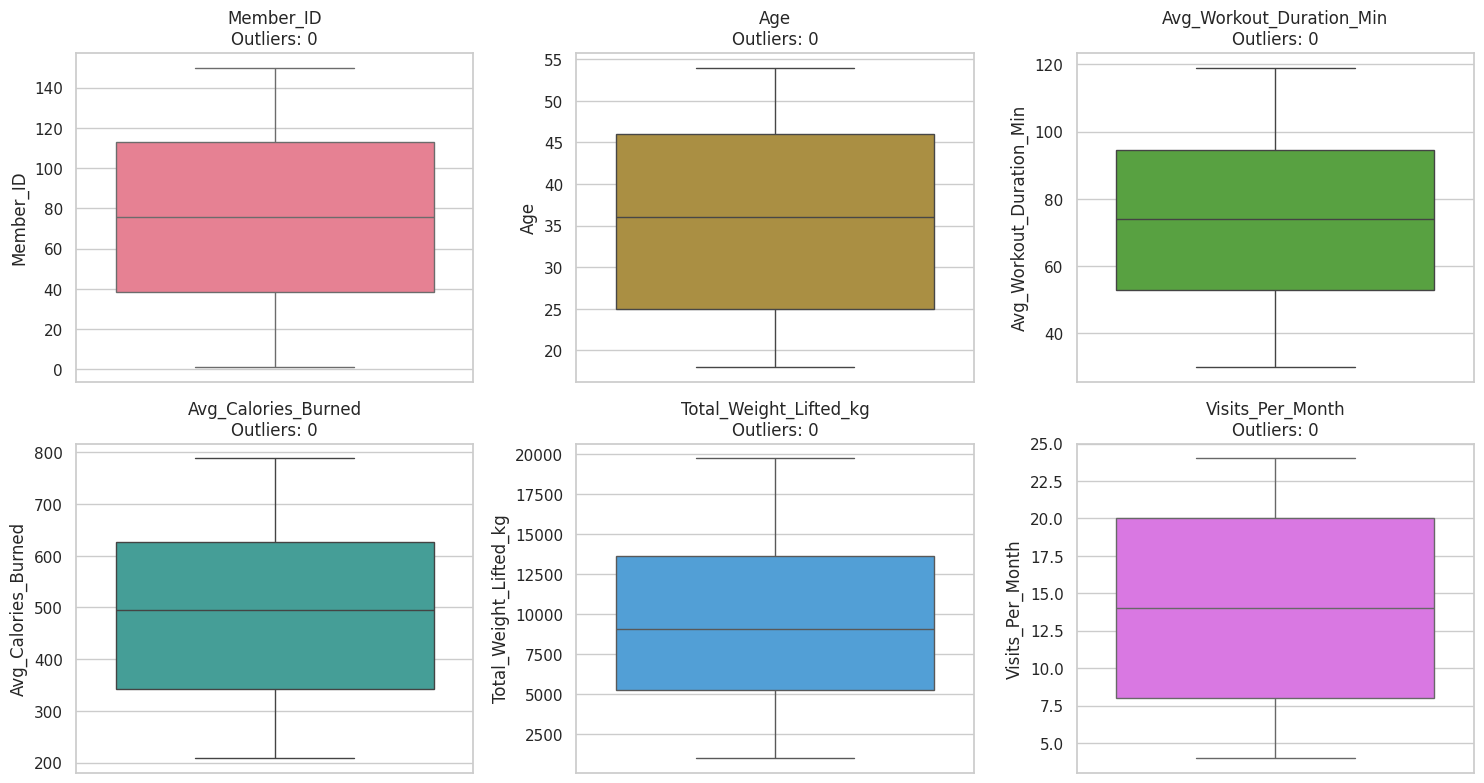

In [15]:
cols = df.select_dtypes(include='number').columns
colors = sns.color_palette("husl", len(cols))

fig, ax = plt.subplots((len(cols)+2)//3, 3, figsize=(15, 4*((len(cols)+2)//3)))
ax = ax.flatten()

for i, (col, color) in enumerate(zip(cols, colors)):
    sns.boxplot(y=df[col], ax=ax[i], color=color)
    q1, q3 = df[col].quantile([.25, .75])
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    ax[i].set_title(f'{col}\nOutliers: {n}')

for j in range(i+1, len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

El análisis de outliers mediante diagramas de caja e IQR no evidencia valores atípicos en las variables numéricas del conjunto de datos. Las distribuciones observadas son relativamente equilibradas y la variabilidad presente parece corresponder al comportamiento normal de los registros, por lo que no sería necesario aplicar tratamientos específicos para outliers en esta etapa del análisis.

# **Visualizaciones del Análisis Exploratorio**

La visualización nos permite encontrar patrones de manera intuitiva. Exploraremos la distribución de nuestra variable objetivo (`Churn`), el comportamiento de variables numéricas y finalmente, cómo se correlacionan las variables entre sí.

## **Distribución de la variable objetivo (Churn)**

La distribución de la variable Churn es especialmente importante porque, tal como se menciona en la descripción del conjunto de datos en Kaggle, esta corresponde a la variable objetivo del problema. En este caso, se busca predecir si un cliente abandonará o no el gimnasio, lo que nos sitúa frente a un problema de clasificación. Por ello, resulta fundamental analizar cómo se distribuyen sus categorías, ya que un desbalance significativo entre clases podría introducir sesgos durante el entrenamiento de los modelos. Esto podría llevar a que el modelo aprenda mejor la clase mayoritaria y tenga dificultades para identificar correctamente los casos de abandono, que suelen ser los más relevantes para el negocio.

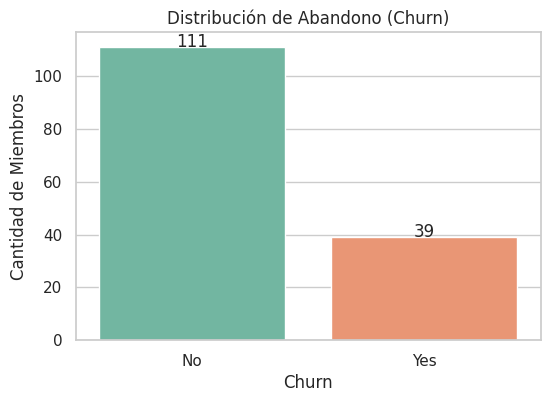

In [16]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x='Churn', palette='Set2')

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width()/2,
        p.get_height(),
        int(p.get_height()),
        ha='center'
    )

plt.title('Distribución de Abandono (Churn)')
plt.ylabel('Cantidad de Miembros')
plt.show()

En este caso se observa una diferencia importante entre ambas categorías de la variable Churn. Mientras que 39 miembros abandonaron el gimnasio, 111 permanecieron activos, lo que indica que la mayoría de los registros corresponden a clientes que no abandonaron el servicio. Esto evidencia un desbalance moderado en la variable objetivo, con una mayor representación de personas que se mantienen en el gimnasio en comparación con aquellas que deciden abandonarlo.

## **Distribución de Edad**

Se decidió profundizar en la variable Age debido a que, desde una perspectiva de negocio, podría tener una influencia importante en las tasas de abandono. Es común que los usuarios más jóvenes comiencen con altos niveles de motivación, pero que posteriormente abandonen sus objetivos por falta de compromiso, cambios de rutina u otros factores. Por ello, resulta interesante analizar la relación entre los distintos rangos de edad y la variable Churn, ya que podría revelar patrones relevantes. Un hallazgo potencial sería identificar si los miembros más jóvenes presentan tasas de abandono superiores a las de los usuarios de mayor edad, información que podría ser útil para diseñar estrategias de retención más efectivas.

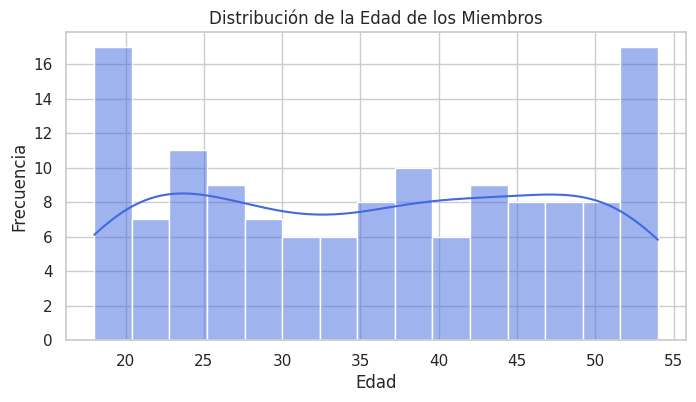

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'].dropna(), kde=True, bins=15, color='royalblue')
plt.title('Distribución de la Edad de los Miembros')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

A primera vista, la variable Age presenta una distribución relativamente uniforme entre los 18 y 54 años, con una cantidad similar de registros en los rangos más jóvenes y más altos. Esto indica una población equilibrada en términos de edad. Sin embargo, dado que la edad podría influir en el abandono, resulta interesante analizar si ciertos grupos etarios presentan mayores tasas de Churn que otros.

Churn,No,Yes
Age_Group,,
18-25,82.14,17.86
26-35,82.76,17.24
36-45,69.44,30.56
46-54,67.57,32.43


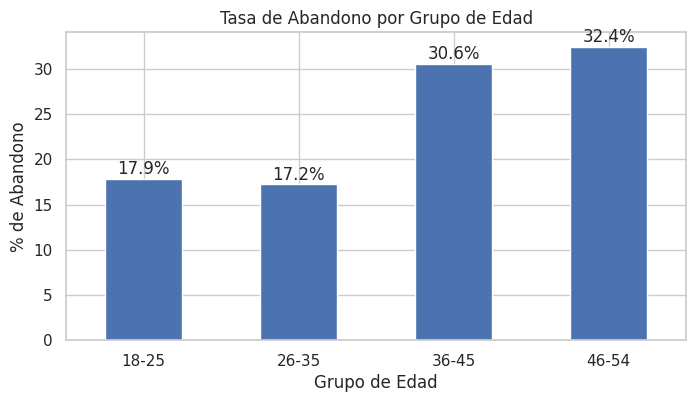

In [18]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 55],
    labels=["18-25", "26-35", "36-45", "46-54"]
)

# Porcentaje de abandono por grupo de edad

tabla = pd.crosstab(
    df["Age_Group"],
    df["Churn"],
    normalize="index"
) * 100

display(tabla.round(2))

# Gráfico
tabla["Yes"].plot(kind="bar", figsize=(8,4))

plt.title("Tasa de Abandono por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("% de Abandono")
plt.xticks(rotation=0)

# Mostrar porcentaje sobre cada barra
for i, v in enumerate(tabla["Yes"]):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.show()

El análisis muestra que la hipótesis inicial era incorrecta, ya que se esperaba una mayor tasa de abandono en los miembros más jóvenes. Sin embargo, los resultados indican que el Churn aumenta con la edad, pasando de aproximadamente un 18% en los grupos más jóvenes a más de un 30% en los grupos de 36 años o más. Este hallazgo resalta la importancia de validar las suposiciones mediante el análisis de datos y sugiere que podrían ser necesarias estrategias de retención enfocadas en los miembros de mayor edad.

## **Duración de entrenamiento según Churn**

Otra pregunta interesante que surge es si las personas que entrenan durante menos tiempo son más propensas a abandonar el gimnasio. Para explorar esta posibilidad, se comparó la duración promedio de los entrenamientos entre los miembros que permanecieron y aquellos que abandonaron el servicio, con el objetivo de identificar si existe alguna relación entre ambas variables.

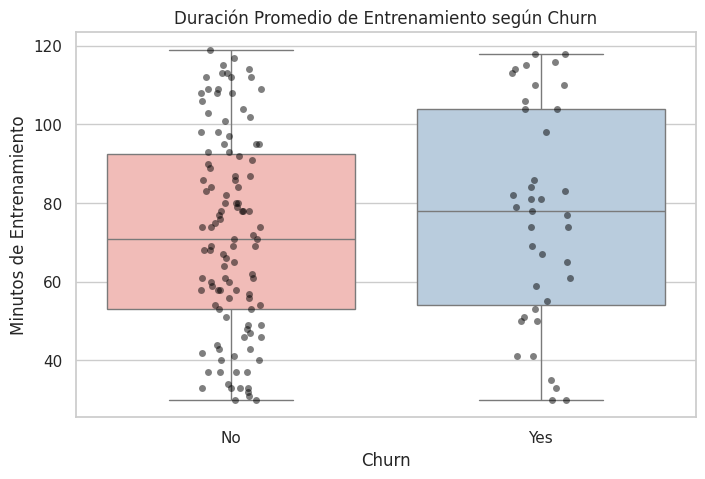

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='Avg_Workout_Duration_Min',
    palette='Pastel1'
)

sns.stripplot(
    data=df,
    x='Churn',
    y='Avg_Workout_Duration_Min',
    color='black',
    alpha=0.5,
    jitter=True
)

plt.title('Duración Promedio de Entrenamiento según Churn')
plt.xlabel('Churn')
plt.ylabel('Minutos de Entrenamiento')
plt.show()

A simple vista, no se observa una diferencia clara en la duración promedio de los entrenamientos entre quienes abandonaron el gimnasio y quienes permanecieron. Aunque los miembros con Churn = Yes presentan una mediana ligeramente superior, el amplio solapamiento entre ambos grupos sugiere que la duración del entrenamiento, por sí sola, no parece ser un factor determinante para explicar el abandono.

## **Correlación entre variables numéricas**

La correlación es uno de los análisis más importantes antes de aplicar cualquier modelo de datos, ya que permite identificar el nivel de relación entre las variables. Esto ayuda a comprender mejor el conjunto de datos y puede orientar la selección de variables y modelos, considerando que no todos los algoritmos se comportan igual frente a distintos tipos de datos.

- **Regresión Lineal:** funciona mejor cuando existe una relación lineal entre las variables. Por ejemplo, predecir el precio de una casa según su tamaño.

* **Árboles de Decisión:** son útiles cuando las relaciones entre las variables son más complejas y no lineales. Por ejemplo, determinar si un cliente comprará un producto según su edad, ingresos y hábitos de compra.

* **K-Nearest Neighbors (KNN):** suele funcionar bien cuando los datos similares tienden a pertenecer a la misma categoría. Por ejemplo, clasificar flores según sus características físicas.

* **Random Forest:** es adecuado para conjuntos de datos con muchas variables y relaciones complejas. Por ejemplo, predecir si un paciente tiene una enfermedad a partir de varios indicadores médicos.

* **Máquinas de Soporte Vectorial (SVM):** pueden ser efectivas cuando las clases están bien separadas. Por ejemplo, distinguir correos electrónicos entre spam y no spam.

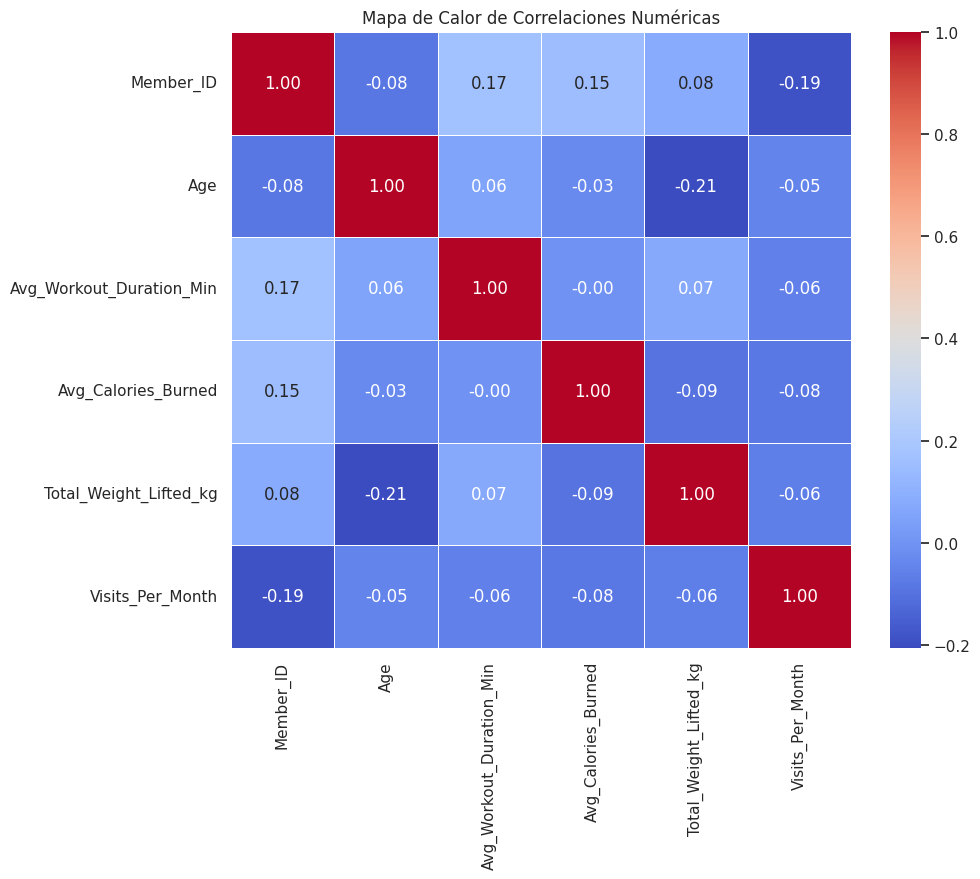

In [20]:
plt.figure(figsize=(10, 8))
# Seleccionamos solo las columnas numéricas para evitar errores de tipo
columnas_numericas = df.select_dtypes(include=[np.number])
correlacion = columnas_numericas.corr()

# Generamos el mapa de calor
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de Correlaciones Numéricas')
plt.show()

El análisis de correlación muestra que las variables tienen relaciones débiles entre sí, ya que ninguna supera un valor de 0.21. Esto indica que no existe una dependencia fuerte entre las variables numéricas, lo que puede ser positivo para los modelos. Además, sugiere que la variable objetivo Churn podría estar influenciada por otros factores o por combinaciones de variables que no se observan directamente en esta correlación.

# **Resumen de Hallazgos**

El análisis exploratorio permitió identificar que el conjunto de datos presenta una buena calidad general. No se detectaron registros duplicados ni inconsistencias en las categorías, lo que reduce la necesidad de realizar procesos complejos de limpieza. Sin embargo, se observaron valores faltantes en campos relevantes como Age, Join_Date, Avg_Calories_Burned, Total_Weight_Lifted_kg y Visits_Per_Month, por lo que será necesario evaluar estrategias de tratamiento específicas para cada caso.

Algunas alternativas que podrían considerarse son:

- Eliminar la variable Name, ya que corresponde a un identificador y no parece aportar información útil para la predicción del abandono.

- Imputación basada en grupos para variables como Age, utilizando información de usuarios con características similares, como género o tipo de membresía.

- KNN Imputer para Visits_Per_Month o Avg_Calories_Burned, aprovechando la similitud entre los hábitos de entrenamiento de los miembros.

- Modelos predictivos de imputación para Total_Weight_Lifted_kg, utilizando variables relacionadas como duración de entrenamiento, calorías quemadas y frecuencia de visitas.

- Ingeniería de variables temporales en Join_Date, transformando la fecha en antigüedad del miembro antes de realizar cualquier imputación.

La estrategia final deberá definirse tras analizar si los datos faltantes presentan algún patrón asociado al comportamiento de los usuarios o a la variable objetivo Churn, evitando aplicar imputaciones simples que puedan introducir sesgos en el análisis.

La variable objetivo Churn presenta un desbalance moderado, con una mayor cantidad de miembros que permanecen en el gimnasio respecto a quienes abandonan el servicio. Este aspecto deberá considerarse durante el modelado mediante técnicas como ajuste de pesos de clase, sobremuestreo o el uso de métricas adecuadas para conjuntos de datos desbalanceados.

Respecto al comportamiento de los usuarios, se observó que la tasa de abandono aumenta en los grupos de mayor edad, contradiciendo la hipótesis inicial de que los miembros más jóvenes serían más propensos a desertar. Por otro lado, la duración promedio de los entrenamientos no mostró diferencias significativas entre quienes abandonan y quienes permanecen en el gimnasio.

Finalmente, las variables numéricas presentan correlaciones débiles entre sí, lo que sugiere una baja dependencia lineal y la posibilidad de que el abandono esté influenciado por combinaciones de factores o por variables categóricas. Debido a ello, modelos capaces de capturar relaciones no lineales, como Árboles de Decisión, Random Forest o Gradient Boosting, podrían ser alternativas prometedoras para abordar el problema de predicción del abandono.